# Example of training NN with attention with history

## Dataset exploration

- Data was prepared beforehand using Rust for speed and utilizing CPU
- Results were pushed to github in order to skip data preprocessing in notebook in case it opens in Google Colab
- Cropping to least common union area shows, that some formulas in dataset consume a lot of height. It creates tradeoff whether to remove them from dataset or to deal with significant blank space
- Right now all lossless optimizations of dataset are processed with Rust and pushed to github repo
- Further space optimizations go in preprocess stage with multithreading and are saved in outputs folder specified in config json file (or default `outputs` in `config.py:9`)

In [ ]:
!sudo apt install aria2c
!aria2c https://zenodo.org/api/records/56198/files-archive

In [ ]:
# !curl https://zenodo.org/api/records/56198/files-archive --output 56198.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  292M    0  292M    0     0  1645k      0 --:--:--  0:03:02 --:--:-- 2434k  0     0  1464k      0 --:--:--  0:00:46 --:--:-- 1532k21k      0 --:--:--  0:01:30 --:--:-- 1965k


In [ ]:
!unzip 56198.zip

In [ ]:
!git clone https://github.com/misssglory/parse-latex

In [ ]:
!mv parse-latex/* . && ls

In [19]:
!cat README.md

4678.70s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


# Translate Latex from images to formula

- [Paper](https://arxiv.org/pdf/1609.04938)


## Dataset preprocess stage

- [Dataset link](https://zenodo.org/records/56198#.V2p0KTXT6eA) 
- Scripts crop images to least common union rectangle and convert to 1-channel format in order to save disk space
- Rust is used in order to preprocess with CPU multithreading

```bash
# Consider dataset is in dataset folder
cd dataset
unzip 56198.zip
tar -xvf formula_images.tar.gz
rm 56198.zip
rm formula_images.tar.gz
cd -
mkdir -p dataset/crop
mkdir -p dataset/formatted
cargo run --release --bin crop_union_formulas -- dataset/formula_images dataset/crop
cargo run --release --bin change_format -- dataset/crop dataset/formatted
rm -r dataset/crop
rm -r dataset/formula_images
```

## Nix environment setup for ROCm (incomplete)
```
nix build .#rocm-cmake
nix build .#libdivide
nix build .#hipsparselt
...
```



## Starting input prompt
```
here is paper to implement image to text attention model for latex form

In [ ]:
!mv parse-latex/.git . || mv parse-latex/.gitignore . || git pull origin main

In [ ]:
!pip install uv && uv venv && . .venv/bin/activate

In [ ]:
!uv pip install -r requirements.txt

In [26]:
!cat configs/fp16.json

6646.39s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


{
  "dataset_dir": "dataset",
  "output_dir": "outputs_fp16",
  "epochs": 20,
  "batch_size": 12,
  "lr": 0.001,
  "seed": 42,
  "max_len": 160,
  "vocab_size": 1800,
  "min_freq": 1,
  "target_height": 128,
  "max_width": 512,
  "scale_factor": 4.0,
  "d_model": 256,
  "emb_dim": 128,
  "dec_dim": 256,
  "attn_dim": 512,
  "visualize_every": 1,
  "precision": "fp16",
  "run_eagerly": false,
  "num_visual_samples": 3,
  "log_file": "train.log"
}

## Example of training with config parameters overriding (may be broken in notebook)

In [34]:
!python train.py --config configs/fp16_from32.json --batch-size 16 --scale-factor 1.0

12272.58s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


I0000 00:00:1774139941.727160  235014 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774139941.727472  235014 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774139941.774744  235014 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774139943.192812  235014 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

- After training it is possible to watch serialized logs and history
- Look into folder specified as `output_dir` in config json or just grep (`rg resolved_config.json`) for path

## Example for continuing of training
- Training attention mechanism may be tedius
- This project is aimed to evaluate performance of ROCm setup for cheap hardware with lots of RAM, so this is quite useful

In [36]:
!python train.py --resume-from outputs_fp16 --epochs 1

12316.68s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


I0000 00:00:1774139985.814664  235177 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774139985.814970  235177 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774139985.861643  235177 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774139987.143861  235177 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

## Loading of trained model and visualization of attention map

In [4]:
test_samples

[{'image_path': 'dataset/formatted/7944775fc9.png',
  'formula': 'i\\Delta ^{ab}(q)=\\frac{-i\\delta ^{ab}}{q^2-\\mu ^2+i\\varepsilon }',
  'render_type': 'basic'},
 {'image_path': 'dataset/formatted/78228211ca.png',
  'formula': '{\\cal A}_{n} : = \\langle \\prod_{j=1}^{m} S^{k_j}_{-l_j} |\\sum_{j=1}^{m} l_j \\geq n \\rangle\\,,',
  'render_type': 'basic'},
 {'image_path': 'dataset/formatted/15b9034ba8.png',
  'formula': '\\label{fierep}P_{(2)}^-=\\int \\beta d\\beta d^9p d^8\\lambda \\Phi(-p,-\\lambda)\\left(-\\frac{p^Ip^I}{2\\beta}\\right) \\Phi(p,\\lambda)\\,.',
  'render_type': 'basic'},
 {'image_path': 'dataset/formatted/6968dfca15.png',
  'formula': '{\\bf E} \\rightarrow - c {{\\bf B}^{\\prime}}\\hspace{1.0in}   c {\\bf B} \\rightarrow {{\\bf E}^{\\prime}}',
  'render_type': 'basic'},
 {'image_path': 'dataset/formatted/6cead0df53.png',
  'formula': 'a^{2}=\\frac{m\\mu }{k^{2}e\\lambda ^{2}_{\\phi }}\\, .',
  'render_type': 'basic'},
 {'image_path': 'dataset/formatted/5381b22df4

In [7]:
model.summary()

Model: "im2_latex_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cnn_encoder (CNNEncoder)        │ ?                      │     2,144,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ row_encoder (RowEncoder)        │ ?                      │       362,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (AttentionDecoder)      │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,571,233 (13.62 MB)

 Trainable params: 3,568,801 (13.61 MB)

 Non-trainable params: 2,432 (9.50 KB)

## Examine saved vocabulary and training history

In [ ]:
# !apt intsall batcat
!cat outputs_fp16_small/vocab.json

6223.57s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


{
  "<pad>": 0,
  "<bos>": 1,
  "<eos>": 2,
  "<unk>": 3,
  "{": 4,
  "}": 5,
  "_": 6,
  "^": 7,
  ")": 8,
  "(": 9,
  "2": 10,
  "-": 11,
  "1": 12,
  "=": 13,
  ",": 14,
  "+": 15,
  "\\frac": 16,
  "0": 17,
  ".": 18,
  "\\label": 19,
  "i": 20,
  "\\,": 21,
  "x": 22,
  "\\mu": 23,
  "\\left": 24,
  "\\right": 25,
  "a": 26,
  "n": 27,
  "&": 28,
  "k": 29,
  "3": 30,
  "\\alpha": 31,
  "\\partial": 32,
  "4": 33,
  "\\;": 34,
  "d": 35,
  "m": 36,
  "A": 37,
  "]": 38,
  "[": 39,
  "p": 40,
  "~": 41,
  "\\over": 42,
  "e": 43,
  "\\nu": 44,
  "|": 45,
  "\\pi": 46,
  "\\ ": 47,
  "r": 48,
  "z": 49,
  "\\phi": 50,
  "'": 51,
  "j": 52,
  "g": 53,
  "\\cal": 54,
  "\\delta": 55,
  "t": 56,
  "\\lambda": 57,
  "q": 58,
  "\\beta": 59,
  "\\int": 60,
  "\\bar": 61,
  "N": 62,
  "c": 63,
  "b": 64,
  "R": 65,
  "\\theta": 66,
  "D": 67,
  "\\sigma": 68,
  "L": 69,
  "/": 70,
  "array": 71,
  "\\\\": 72,
  "F": 73,
  "\\gamma": 74,
  "f": 75,
  "M": 76,
  "S": 77,
  "\\hat": 78,
  "T

## Training in notebook

In [13]:
%matplotlib inline

import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import tensorflow as tf

from config import TrainConfig
from utils import setup_precision, set_seed, setup_logging
from data import load_formulas, load_split, Vocab
from train import make_datasets_for, prepare_model, train_model, evaluate_model
from history_utils import load_history

In [14]:
cfg = TrainConfig(
    dataset_dir="dataset",
    output_dir="outputs_notebook2",
    epochs=3,
    batch_size=12,
    lr=1e-2,
    max_len=160,
    target_height=128,
    max_width=512,
    scale_factor=1.0,
    precision="fp16",
    shard_size=256,
    num_preprocess_workers=8,
    cache_preprocessed=True,
    visualize_every=1,
    num_visual_samples=3,
)

os.makedirs(cfg.output_dir, exist_ok=True)
logger, log_path = setup_logging(cfg.output_dir, base_name="train")
print("log:", log_path)

setup_precision(cfg.precision)
set_seed(cfg.seed)
cfg.save_json(os.path.join(cfg.output_dir, "resolved_config.json"))

log: outputs_notebook2/train-20260327_001533.log
2026-03-27 00:15:33.968 | INFO     | utils:setup_precision:37 - Mixed precision policy set to <DTypePolicy "mixed_float16">
2026-03-27 00:15:33.968 | WARNING  | utils:setup_precision:39 - fp16 selected but no GPU detected; on CPU this may be slower.


In [15]:
formulas = load_formulas(os.path.join(cfg.dataset_dir, "im2latex_formulas.lst"))

train_samples = load_split(
    os.path.join(cfg.dataset_dir, "im2latex_train.lst"),
    formulas,
    os.path.join(cfg.dataset_dir, "formatted"),
)
val_samples = load_split(
    os.path.join(cfg.dataset_dir, "im2latex_validate.lst"),
    formulas,
    os.path.join(cfg.dataset_dir, "formatted"),
)
test_samples = load_split(
    os.path.join(cfg.dataset_dir, "im2latex_test.lst"),
    formulas,
    os.path.join(cfg.dataset_dir, "formatted"),
)

train_formulas = [s["formula"] for s in train_samples]
vocab = Vocab.build(train_formulas, min_freq=cfg.min_freq, max_size=cfg.vocab_size)
vocab.save(os.path.join(cfg.output_dir, "vocab.json"))

2026-03-27 00:15:34.409 | WARNING  | data:read_text_auto:99 - Failed reading dataset/im2latex_formulas.lst with encoding=utf-8: 'utf-8' codec can't decode byte 0xe7 in position 854136: invalid continuation byte
2026-03-27 00:15:34.412 | WARNING  | data:read_text_auto:99 - Failed reading dataset/im2latex_formulas.lst with encoding=utf-8-sig: 'utf-8' codec can't decode byte 0xe7 in position 854136: invalid continuation byte
2026-03-27 00:15:34.441 | INFO     | data:read_text_auto:95 - Read dataset/im2latex_formulas.lst with encoding=cp1252
2026-03-27 00:15:34.463 | INFO     | data:load_formulas:107 - Loaded 104564 formulas from dataset/im2latex_formulas.lst using encoding=cp1252


In [16]:
train_ds, val_ds, test_ds = make_datasets_for(
    cfg, vocab, train_samples, val_samples, test_samples)

2026-03-27 00:15:37.407 | INFO     | data:build_preprocessed_split:230 - Found preprocessed manifest for split=train: outputs_notebook2/preprocessed/train/manifest.json
2026-03-27 00:15:37.407 | INFO     | data:build_preprocessed_split:230 - Found preprocessed manifest for split=val: outputs_notebook2/preprocessed/val/manifest.json
2026-03-27 00:15:37.408 | INFO     | data:build_preprocessed_split:230 - Found preprocessed manifest for split=test: outputs_notebook2/preprocessed/test/manifest.json


In [5]:
model = prepare_model(cfg, vocab)
model.summary(expand_nested=True)

E0000 00:00:1774466176.840748   15963 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
/home/mg/gh/cp-parse-latex/.venv/lib/python3.13/site-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'im2_latex_model', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "im2_latex_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cnn_encoder (CNNEncoder)        │ ?                      │     2,144,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ row_encoder (RowEncoder)        │ ?                      │       362,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (AttentionDecoder)      │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,571,233 (13.62 MB)

 Trainable params: 3,568,801 (13.61 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [6]:
best_ckpt = os.path.join(cfg.output_dir, "checkpoints", "best.weights.h5")
if os.path.exists(best_ckpt):
    model.load_weights(best_ckpt)
    print("Loaded checkpoint:", best_ckpt)

In [7]:
history = load_history(os.path.join(cfg.output_dir, cfg.history_file))
print({k: len(v) for k, v in history.items()})

{'loss': 0, 'val_loss': 0, 'token_acc': 0, 'val_token_acc': 0}


In [8]:
model, history = train_model(
    cfg=cfg,
    model=model,
    vocab=vocab,
    train_samples=train_samples,
    val_samples=val_samples,
    train_ds=train_ds,
    val_ds=val_ds,
    history=history,
)

2026-03-25 22:16:31.151 | INFO     | train:train_model:255 - epoch 1/3


I0000 00:00:1774466191.167211   15963 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


   6991/Unknown 40441s 6s/step - loss: 3.1040 - token_acc: 0.3529

/home/mg/gh/cp-parse-latex/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


6991/6991 ━━━━━━━━━━━━━━━━━━━━ 41383s 6s/step - loss: 2.6673 - token_acc: 0.4237 - val_loss: 2.3616 - val_token_acc: 0.4708
2026-03-26 09:46:14.867 | INFO     | train:train_model:283 - new best checkpoint: outputs_notebook2/checkpoints/best.weights.h5, val_loss=2.361617
2026-03-26 09:46:21.461 | INFO     | train:sample_visualization:242 - saved sample visualization: outputs_notebook2/samples/epoch_0001.png
2026-03-26 09:46:21.463 | INFO     | train:train_model:255 - epoch 2/3
6991/6991 ━━━━━━━━━━━━━━━━━━━━ 39759s 6s/step - loss: 2.2926 - token_acc: 0.4815 - val_loss: 2.2852 - val_token_acc: 0.4823
2026-03-26 20:49:01.029 | INFO     | train:train_model:283 - new best checkpoint: outputs_notebook2/checkpoints/best.weights.h5, val_loss=2.285169
2026-03-26 20:49:07.178 | INFO     | train:sample_visualization:242 - saved sample visualization: outputs_notebook2/samples/epoch_0002.png
2026-03-26 20:49:07.178 | INFO     | train:train_model:255 - epoch 3/3
    762/Unknown 4315s 6s/step - loss: 

KeyboardInterrupt: 

## Continue training in notebook example

In [ ]:
%matplotlib inline

import os
os.environ["KERAS_BACKEND"] = "tensorflow"

from config import TrainConfig
from utils import setup_precision, set_seed, setup_logging
from data import load_formulas, load_split, Vocab
from train import make_datasets_for, prepare_model, train_model, evaluate_model
from history_utils import load_history

resume_dir = "outputs_notebook2"

cfg = TrainConfig.load_json(os.path.join(resume_dir, "resolved_config.json"))
cfg.output_dir = resume_dir
cfg.epochs = 3  # number of ADDITIONAL epochs to train now

logger, log_path = setup_logging(cfg.output_dir, base_name="train")
print("log:", log_path)

setup_precision(cfg.precision)
set_seed(cfg.seed)

formulas = load_formulas(os.path.join(cfg.dataset_dir, "im2latex_formulas.lst"))

train_samples = load_split(
    os.path.join(cfg.dataset_dir, "im2latex_train.lst"),
    formulas,
    os.path.join(cfg.dataset_dir, "formatted"),
)
val_samples = load_split(
    os.path.join(cfg.dataset_dir, "im2latex_validate.lst"),
    formulas,
    os.path.join(cfg.dataset_dir, "formatted"),
)
test_samples = load_split(
    os.path.join(cfg.dataset_dir, "im2latex_test.lst"),
    formulas,
    os.path.join(cfg.dataset_dir, "formatted"),
)

vocab = Vocab.load(os.path.join(cfg.output_dir, "vocab.json"))

train_ds, val_ds, test_ds = make_datasets_for(
   cfg, vocab, train_samples, val_samples, test_samples
)

model = prepare_model(cfg, vocab)

best_ckpt = os.path.join(cfg.output_dir, "checkpoints", "best.weights.h5")
model.load_weights(best_ckpt)
print("Loaded checkpoint:", best_ckpt)

history = load_history(os.path.join(cfg.output_dir, cfg.history_file))
print({k: len(v) for k, v in history.items()})

model, history = train_model(
    cfg=cfg,
    model=model,
    vocab=vocab,
    train_samples=train_samples,
    val_samples=val_samples,
    train_ds=train_ds,
    val_ds=val_ds,
    history=history,
)

metrics = evaluate_model(
    model=model,
    vocab=vocab,
    test_samples=test_samples,
    test_ds=test_ds,
    cfg=cfg,
)
metrics

log: outputs_notebook2/train-20260326_234526.log
2026-03-26 23:45:26.539 | INFO     | utils:setup_precision:37 - Mixed precision policy set to <DTypePolicy "mixed_float16">
2026-03-26 23:45:26.540 | WARNING  | utils:setup_precision:39 - fp16 selected but no GPU detected; on CPU this may be slower.
2026-03-26 23:45:26.557 | WARNING  | data:read_text_auto:99 - Failed reading dataset/im2latex_formulas.lst with encoding=utf-8: 'utf-8' codec can't decode byte 0xe7 in position 854136: invalid continuation byte
2026-03-26 23:45:26.574 | WARNING  | data:read_text_auto:99 - Failed reading dataset/im2latex_formulas.lst with encoding=utf-8-sig: 'utf-8' codec can't decode byte 0xe7 in position 854136: invalid continuation byte
2026-03-26 23:45:26.599 | INFO     | data:read_text_auto:95 - Read dataset/im2latex_formulas.lst with encoding=cp1252
2026-03-26 23:45:26.620 | INFO     | data:load_formulas:107 - Loaded 104564 formulas from dataset/im2latex_formulas.lst using encoding=cp1252
2026-03-26 23:4

/home/mg/gh/cp-parse-latex/.venv/lib/python3.13/site-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'im2_latex_model', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/home/mg/gh/cp-parse-latex/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 4 variables whereas the saved optimizer has 98 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/mg/gh/cp-parse-latex/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 94 variables. 
  saveabl

Loaded checkpoint: outputs_notebook2/checkpoints/best.weights.h5
{'loss': 2, 'val_loss': 2, 'token_acc': 2, 'val_token_acc': 2}
2026-03-26 23:45:43.581 | INFO     | train:train_model:255 - epoch 1/3
    171/Unknown 1189s 6s/step - loss: 2.3007 - token_acc: 0.4761

# Evaluate and render attention maps

In [7]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from config import TrainConfig
from data import load_formulas, load_split, Vocab, preprocess_image
from model import Im2LatexModel
from metrics import char_diff, compile_latex_formula
from utils import setup_precision, set_seed


# 1) Load config and setup
outputs_folder = 'outputs_notebook2'

cfg_path = f"{outputs_folder}/resolved_config.json"
cfg = TrainConfig.load_json(cfg_path)
cfg.output_dir = outputs_folder

# 2) Load formulas + test split
formulas = load_formulas(os.path.join(cfg.dataset_dir, "im2latex_formulas.lst"))
test_samples = load_split(
    os.path.join(cfg.dataset_dir, "im2latex_test.lst"),
    formulas,
    os.path.join(cfg.dataset_dir, "formatted"),
)

# 3) Load vocab
vocab = Vocab.load(os.path.join(cfg.output_dir, "vocab.json"))

# 4) Build model and load weights
setup_precision(cfg.precision)
set_seed(cfg.seed)

model = Im2LatexModel(
    vocab_size=len(vocab.token_to_id),
    d_model=cfg.d_model,
    emb_dim=cfg.emb_dim,
    dec_dim=cfg.dec_dim,
    attn_dim=cfg.attn_dim,
    bos_id=vocab.bos_id,
    eos_id=vocab.eos_id,
    pad_id=vocab.pad_id,
    name="im2_latex_model",
)

dummy_images = tf.zeros([1, cfg.target_height, 128, 1], dtype=tf.float32)
dummy_tgt = tf.zeros([1, cfg.max_len - 1], dtype=tf.int32)
_ = model((dummy_images, dummy_tgt), training=False)

best_ckpt = os.path.join(cfg.output_dir, "checkpoints", "best.weights.h5")
model.load_weights(best_ckpt)
print("Loaded:", best_ckpt)

2026-03-27 00:12:32.204 | WARNING  | data:read_text_auto:99 - Failed reading dataset/im2latex_formulas.lst with encoding=utf-8: 'utf-8' codec can't decode byte 0xe7 in position 854136: invalid continuation byte
2026-03-27 00:12:32.242 | WARNING  | data:read_text_auto:99 - Failed reading dataset/im2latex_formulas.lst with encoding=utf-8-sig: 'utf-8' codec can't decode byte 0xe7 in position 854136: invalid continuation byte
2026-03-27 00:12:32.325 | INFO     | data:read_text_auto:95 - Read dataset/im2latex_formulas.lst with encoding=cp1252
2026-03-27 00:12:32.349 | INFO     | data:load_formulas:107 - Loaded 104564 formulas from dataset/im2latex_formulas.lst using encoding=cp1252
2026-03-27 00:12:32.368 | INFO     | utils:setup_precision:37 - Mixed precision policy set to <DTypePolicy "mixed_float16">
2026-03-27 00:12:32.369 | WARNING  | utils:setup_precision:39 - fp16 selected but no GPU detected; on CPU this may be slower.
E0000 00:00:1774559552.593750  444021 util.cc:131] oneDNN suppor

Loaded: outputs_notebook2/checkpoints/best.weights.h5


In [ ]:
from loguru import logger
import matplotlib.pyplot as plt
import os

def visualize_single_sample(idx, max_len=None, save_path=None, colormap=cv2.COLORMAP_JET, show=True):
    """
    Visualize a single sample and optionally save it.
    
    Args:
        idx: Sample index
        max_len: Maximum sequence length for decoding
        save_path: Path to save the image (if None, doesn't save)
        colormap: Colormap for attention overlay
        show: Whether to display the figure
    """
    if max_len is None:
        max_len = cfg.max_len - 1
    
    # Get sample
    sample = test_samples[idx]
    
    # Process image
    img = preprocess_image(
        sample["image_path"],
        target_height=cfg.target_height,
        max_width=cfg.max_width,
        scale_factor=cfg.scale_factor,
    )
    
    # Run inference
    batch = tf.convert_to_tensor(img[None, ...], dtype=tf.float32)
    pred_ids, attn = model.greedy_decode(batch, max_len=max_len)
    
    # Decode predictions
    pred_formula = vocab.decode(pred_ids[0].numpy())
    gt_formula = sample["formula"]
    
    # Process attention
    avg_attn = tf.reduce_mean(attn[0], axis=0).numpy()
    
    # Get metrics
    compiles, _ = compile_latex_formula(pred_formula)
    diff = char_diff(gt_formula, pred_formula)
    
    # Log sample information
    logger.info(f"Sample {idx}")
    logger.info(f"  GT:   {gt_formula}")
    logger.info(f"  PRED: {pred_formula}")
    logger.info(f"  Compiles: {compiles} | Char Diff: {diff}")
    
    # Create attention overlay
    blended = overlay_attention(img, avg_attn, colormap=colormap)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(blended)
    ax.axis("off")
    ax.set_title(f"Sample {idx} | Compiles: {compiles} | Diff: {diff}", 
                 fontsize=10, pad=10)
    
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        os.makedirs(os.path.dirname(save_path) if os.path.dirname(save_path) else '.', 
                   exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        logger.info(f"  Saved to: {save_path}")
    
    # Show if requested
    if show:
        plt.show()
    else:
        plt.close()
    
    return {
        'idx': idx,
        'gt': gt_formula,
        'pred': pred_formula,
        'compiles': compiles,
        'diff': diff,
        'image': blended
    }

def visualize_samples_separately(sample_indices, max_len=None, save_dir=None, 
                                 colormap=cv2.COLORMAP_JET, show=True):
    """
    Visualize multiple samples separately.
    
    Args:
        sample_indices: List of sample indices to visualize
        max_len: Maximum sequence length for decoding
        save_dir: Directory to save images (if None, doesn't save)
        colormap: Colormap for attention overlay
        show: Whether to display the figures
    """
    logger.info(f"Visualizing {len(sample_indices)} samples separately")
    
    results = []
    for i, idx in enumerate(sample_indices):
        logger.info(f"\n--- Sample {i+1}/{len(sample_indices)} ---")
        
        save_path = None
        if save_dir:
            save_path = os.path.join(save_dir, f"sample_{idx}.png")
        
        result = visualize_single_sample(
            idx=idx,
            max_len=max_len,
            save_path=save_path,
            colormap=colormap,
            show=show
        )
        results.append(result)
    
    logger.info(f"\nCompleted visualization of {len(sample_indices)} samples")
    return results

# Usage example:
# results = visualize_samples_separately(
#     sample_indices=[0, 5, 10],
#     save_dir="./attention_vis",
#     colormap=cv2.COLORMAP_JET,
#     show=True
# )

2026-03-26 23:42:44.080 | INFO     | __main__:visualize_samples_separately:97 - Visualizing 3 samples separately
2026-03-26 23:42:44.082 | INFO     | __main__:visualize_samples_separately:101 - 
--- Sample 1/3 ---
2026-03-26 23:42:46.418 | INFO     | __main__:visualize_single_sample:46 - Sample 6777
2026-03-26 23:42:46.419 | INFO     | __main__:visualize_single_sample:47 -   GT:   \label{cri}B= \zeta^2 v_0 N L \ge B_c = 1.14~,
2026-03-26 23:42:46.419 | INFO     | __main__:visualize_single_sample:48 -   PRED: \label{<unk>}{\calL}_{\rm<unk>}=-\frac{1}{2}\intd^4x\sqrt{-g}\left(\frac{1}{2}g^{\mu\nu}\partial_\mu\phi\partial_\nu\phi\right).
2026-03-26 23:42:46.420 | INFO     | __main__:visualize_single_sample:49 -   Compiles: False | Char Diff: \label{[+<unk>}{\+]c[+alL}_{\rm<unk>}=-\frac{1}{2}\intd^4x\sqrt{-g}\left(\frac{1}{2}g^{\mu\nu}\partial_\mu\phi\partial_\nu\phi\+]ri[-}B= \ze-][+gh+]t[-a^2 v_0 N L \ge B_c = 1-][+)+].[-14~,-]


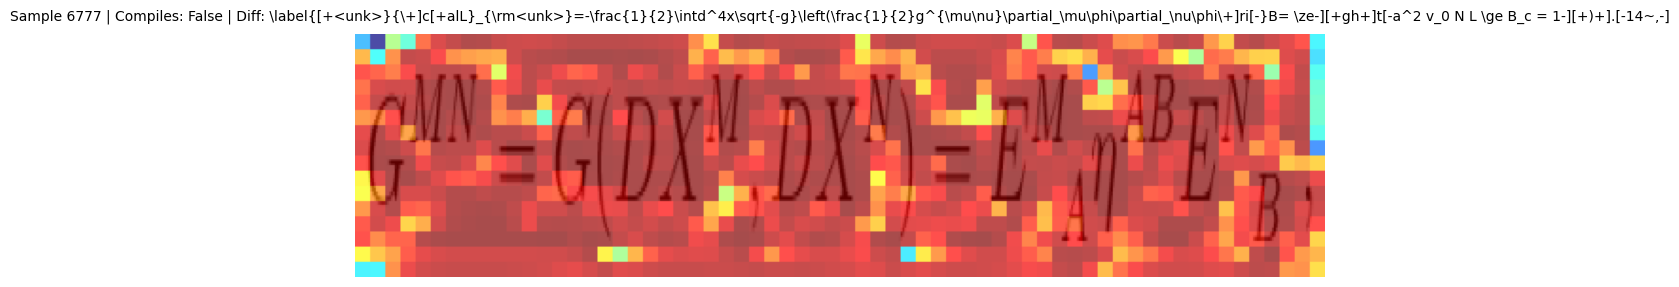

2026-03-26 23:42:46.482 | INFO     | __main__:visualize_samples_separately:101 - 
--- Sample 2/3 ---
2026-03-26 23:42:48.829 | INFO     | __main__:visualize_single_sample:46 - Sample 5090
2026-03-26 23:42:48.830 | INFO     | __main__:visualize_single_sample:47 -   GT:   (\Psi_{WW}k)(x,y)\ =\ a(x,y)\, \left( \matrix {1 & 0  & 0  & 0 \cr 0 & \frac{xy(q^2-1)}{q^2x^2-y^2} &\frac{q(x^2-y^2)}{q^2x^2-y^2} & 0 \cr0 & \frac{q(x^2-y^2)}{q^2x^2-y^2} &\frac{xy(q^2-1)}{q^2x^2-y^2} & 0 \cr0 & 0 & 0 & 1}\right)\, k(y,x)\ ,
2026-03-26 23:42:48.830 | INFO     | __main__:visualize_single_sample:48 -   PRED: \label{<unk>}{\calL}_{\rm<unk>}=-\frac{1}{2}\intd^4x\sqrt{-g}\left(\frac{1}{2}\frac{1}{2}\right)^{-1}\left(\frac{1}{2}\right)^{-1}\left(\frac{1}{2}\right)^{-1}\left(\frac{1}{2}\right)^{-1}\left(\frac{1}{2}\right)^{-1}\left(\frac{1}{2}\right)^{-1}\left(\frac{1}{2}\right)^{\frac{1}{2}}\left(\frac
2026-03-26 23:42:48.831 | INFO     | __main__:visualize_single_sample:49 -   Compiles: False | Char Diff: [

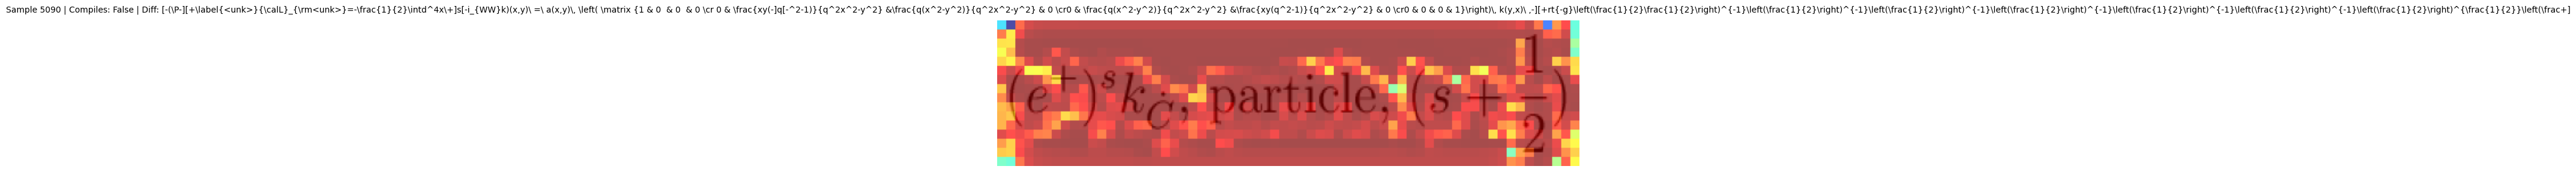

2026-03-26 23:42:48.915 | INFO     | __main__:visualize_samples_separately:101 - 
--- Sample 3/3 ---
2026-03-26 23:42:51.085 | INFO     | __main__:visualize_single_sample:46 - Sample 6859
2026-03-26 23:42:51.086 | INFO     | __main__:visualize_single_sample:47 -   GT:   w=\frac12 \left(\zeta+ \frac{1}{\zeta}\right) \ ,\label{defw}
2026-03-26 23:42:51.086 | INFO     | __main__:visualize_single_sample:48 -   PRED: \label{<unk>}{\calL}_{\rm<unk>}=-{1\over2}\intd^4x\sqrt{-g}\left({1\over2}{\rmTr}({\calA}_{\mu\nu}+{\calF}_{\mu\nu}+{\calF}_{\mu\nu})\right).
2026-03-26 23:42:51.087 | INFO     | __main__:visualize_single_sample:49 -   Compiles: False | Char Diff: [-w-][+\label{<unk>}{\calL}_{\rm<unk>}+]=[+-{1+]\[-f-][+ove+]r[-ac1-]2[- -][+}\intd^4x\sqrt{-g}+]\left([-\zeta+ \frac-]{1[+\over2+]}{\[-zet-][+rmTr}({\c+]a[+lA+]}[+_{\mu\nu}+{\calF}_{\mu\nu}+{\calF}_{\mu\nu})+]\right)[- \ ,\label{defw}-][+.+]


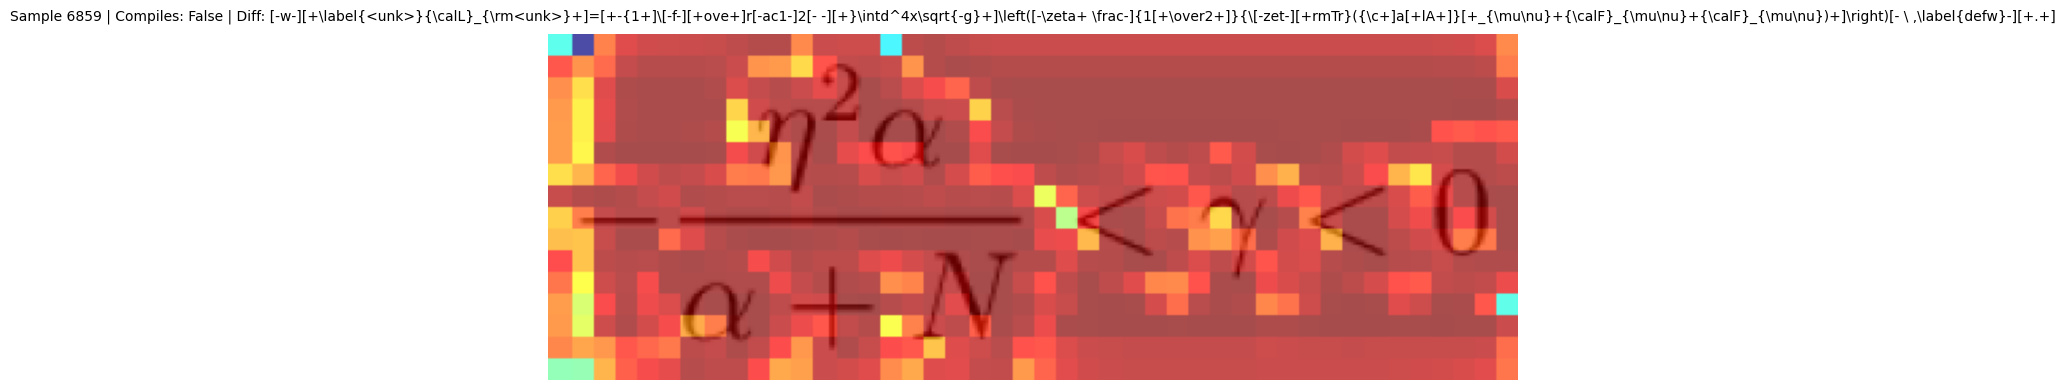

2026-03-26 23:42:51.156 | INFO     | __main__:visualize_samples_separately:116 - 
Completed visualization of 3 samples


[{'idx': np.int64(6777),
  'gt': '\\label{cri}B= \\zeta^2 v_0 N L \\ge B_c = 1.14~,',
  'pred': '\\label{<unk>}{\\calL}_{\\rm<unk>}=-\\frac{1}{2}\\intd^4x\\sqrt{-g}\\left(\\frac{1}{2}g^{\\mu\\nu}\\partial_\\mu\\phi\\partial_\\nu\\phi\\right).',
  'compiles': False,
  'diff': '\\label{[+<unk>}{\\+]c[+alL}_{\\rm<unk>}=-\\frac{1}{2}\\intd^4x\\sqrt{-g}\\left(\\frac{1}{2}g^{\\mu\\nu}\\partial_\\mu\\phi\\partial_\\nu\\phi\\+]ri[-}B= \\ze-][+gh+]t[-a^2 v_0 N L \\ge B_c = 1-][+)+].[-14~,-]',
  'image': array([[[ 76, 191, 255],
          [ 76, 191, 255],
          [ 76, 191, 255],
          ...,
          [ 76, 247, 255],
          [ 76, 247, 255],
          [ 76, 247, 255]],
  
         [[ 76, 191, 255],
          [ 76, 191, 255],
          [ 76, 191, 255],
          ...,
          [ 76, 247, 255],
          [ 76, 247, 255],
          [ 76, 247, 255]],
  
         [[ 76, 191, 255],
          [ 76, 191, 255],
          [ 76, 191, 255],
          ...,
          [ 76, 247, 255],
          [ 76, 2

In [8]:
np.random.seed(0)
indices = np.random.choice(len(test_samples), size=3, replace=False)
visualize_samples_separately(indices)

## Render saved history

In [9]:
from config import TrainConfig
from utils import setup_precision, set_seed
import os


cfg = TrainConfig(
    dataset_dir="dataset",
    output_dir="outputs_notebook",
    epochs=3,
    batch_size=12,
    lr=1e-2,
    max_len=160,
    target_height=128,
    max_width=512,
    scale_factor=1.0,
    precision="fp32",
    cache_preprocessed=True,  # you can set True if you have the cache logic
)

os.makedirs(cfg.output_dir, exist_ok=True)
setup_precision(cfg.precision)
set_seed(cfg.seed)

2026-03-27 00:14:42.613 | INFO     | utils:setup_precision:37 - Mixed precision policy set to <DTypePolicy "float32">


In [18]:
model.compile()

{'loss': 2, 'val_loss': 2, 'token_acc': 2, 'val_token_acc': 2}


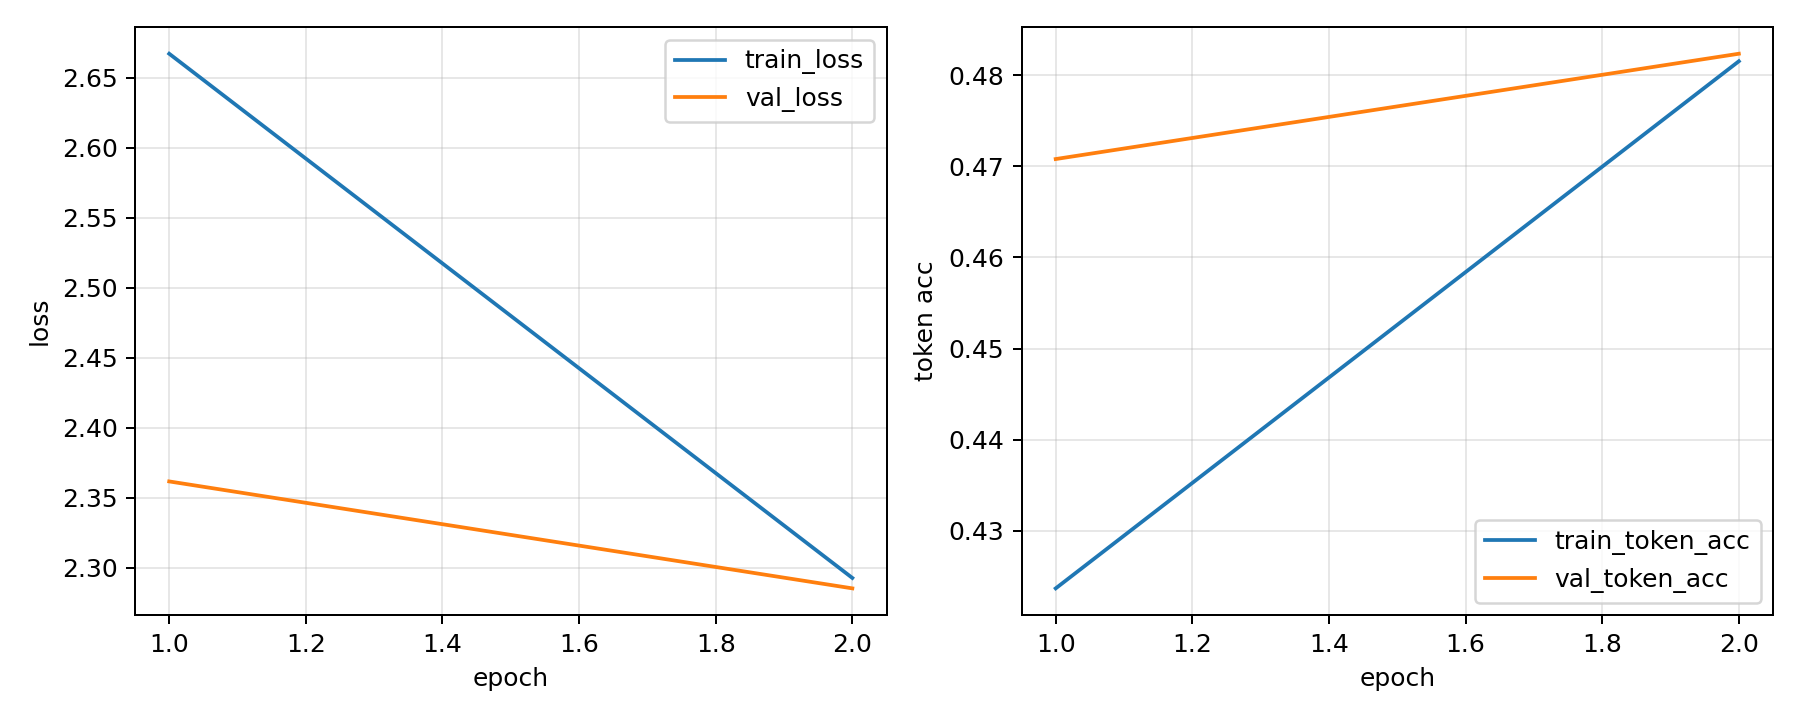

In [22]:
from history_utils import plot_history

history = load_history(os.path.join(cfg.output_dir, cfg.history_file))
print({k: len(v) for k, v in history.items()})

plot_history(history, os.path.join(cfg.output_dir, "history_nb.png"))
from IPython.display import Image

Image(filename=os.path.join(cfg.output_dir, "history_nb.png"))